# Grounded SAM2 Video Tracking

This notebook implements video tracking using Grounding DINO for initial detection and SAM2 for propagation.

In [3]:
import os
import cv2
import torch
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import supervision as sv

from sam2.build_sam import build_sam2_video_predictor, build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

# Device setup
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# Enable optimizations for newer GPUs
torch.autocast(device_type="cuda", dtype=torch.bfloat16).__enter__()
if torch.cuda.get_device_properties(0).major >= 8:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

Using device: cuda


In [6]:
# Video Configuration
HOME = os.getcwd()
SOURCE_VIDEO = r"demo 7.mp4"
SCALE_FACTOR = 0.5
START_IDX = 0
END_IDX = 1000

# Text prompt for Grounding DINO (lowercase + end with dot)
TEXT_PROMPT = "medical tool."

# Output paths
SOURCE_FRAMES = Path(HOME) / Path(SOURCE_VIDEO).stem
TARGET_VIDEO = Path(HOME) / f"{Path(SOURCE_VIDEO).stem}-grounded-result.mp4"

print(f"Source video: {SOURCE_VIDEO}")
print(f"Frames directory: {SOURCE_FRAMES}")
print(f"Output video: {TARGET_VIDEO}")

Source video: demo 7.mp4
Frames directory: c:\Users\asiel\OneDrive\Documents\Trackimed_New\demo 7
Output video: c:\Users\asiel\OneDrive\Documents\Trackimed_New\demo 7-grounded-result.mp4


In [7]:
# Extract and scale video frames
SOURCE_FRAMES.mkdir(parents=True, exist_ok=True)

frames_generator = sv.get_video_frames_generator(SOURCE_VIDEO, start=START_IDX, end=END_IDX)
images_sink = sv.ImageSink(
    target_dir_path=SOURCE_FRAMES.as_posix(),
    overwrite=True,
    image_name_pattern="{:05d}.jpeg"
)

with images_sink:
    for frame in tqdm(frames_generator, desc="Extracting frames"):
        frame = sv.scale_image(frame, SCALE_FACTOR)
        images_sink.save_image(frame)

print(f"Frames extracted to {SOURCE_FRAMES}")

Extracting frames: 1000it [00:38, 25.68it/s]

Frames extracted to c:\Users\asiel\OneDrive\Documents\Trackimed_New\demo 7


In [8]:
# Load SAM2 models
CHECKPOINT = f"{HOME}/checkpoints/sam2.1_hiera_large.pt"
CONFIG = r"C:\Users\asiel\OneDrive\Documents\Trackimed_New\segment-anything-2\sam2\configs\sam2.1\sam2.1_hiera_l.yaml"

sam2_video_predictor = build_sam2_video_predictor(CONFIG, CHECKPOINT)
sam2_image_model = build_sam2(CONFIG, CHECKPOINT, device=DEVICE)
sam2_image_predictor = SAM2ImagePredictor(sam2_image_model)

print("SAM2 models loaded successfully")

SAM2 models loaded successfully


In [9]:
# Load Grounding DINO model
model_id = "IDEA-Research/grounding-dino-base"
processor = AutoProcessor.from_pretrained(model_id)
grounding_model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(DEVICE)

print("Grounding DINO model loaded successfully")

Grounding DINO model loaded successfully


In [13]:
# Run Grounding DINO on first frame to detect objects
IMAGE_PATH = SOURCE_FRAMES / "00000.jpeg"
image = Image.open(IMAGE_PATH).convert("RGB")

# Process with Grounding DINO
inputs = processor(images=image, text=TEXT_PROMPT, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = grounding_model(**inputs)

results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    target_sizes=[image.size[::-1]]
)

# Apply thresholds and extract boxes and labels
BOX_THRESHOLD = 0.40
TEXT_THRESHOLD = 0.50

# Filter by score threshold
scores = results[0]["scores"]
keep = scores > BOX_THRESHOLD

input_boxes = results[0]["boxes"][keep].cpu().numpy()
labels = [results[0]["labels"][i] for i in range(len(keep)) if keep[i]]

print(f"Detected {len(input_boxes)} objects: {labels}")

Detected 16 objects: ['medical tool', 'medical tool', 'medical tool', 'medical tool', 'medical tool', 'medical tool', 'medical tool', 'medical tool', 'medical tool', 'medical tool', 'medical tool', 'medical tool', 'medical tool', 'medical tool', 'medical tool', 'medical tool']


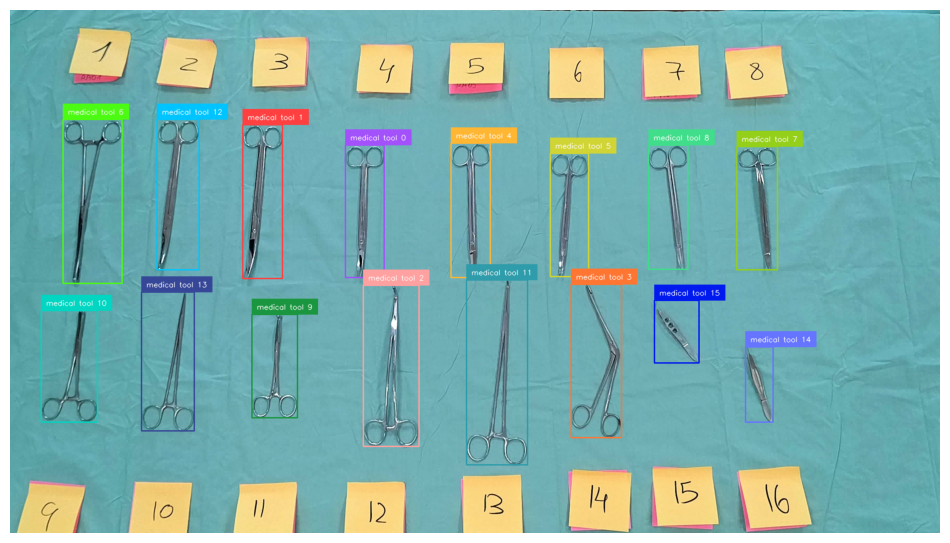

In [14]:
# Visualize detections
detections = sv.Detections(xyxy=input_boxes)
detections.class_id = np.arange(len(input_boxes))

annotated_image = image.copy()
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = box_annotator.annotate(annotated_image, detections)
annotated_image = label_annotator.annotate(annotated_image, detections, labels=[f"{l} {i}" for i, l in enumerate(labels)])

sv.plot_image(annotated_image)

In [15]:
# Use SAM2 image predictor to get masks for detected objects
sam2_image_predictor.set_image(np.array(image))

masks, scores, logits = sam2_image_predictor.predict(
    box=input_boxes,
    multimask_output=True
)

# Select best mask for each detection based on IoU scores
best_mask_indices = scores.argmax(axis=1)
best_masks = masks[np.arange(len(best_mask_indices)), best_mask_indices]

# Add masks to detections
detections.mask = best_masks.astype(bool)

print(f"Generated {len(best_masks)} masks with shape {best_masks.shape}")

Generated 16 masks with shape (16, 1080, 1920)


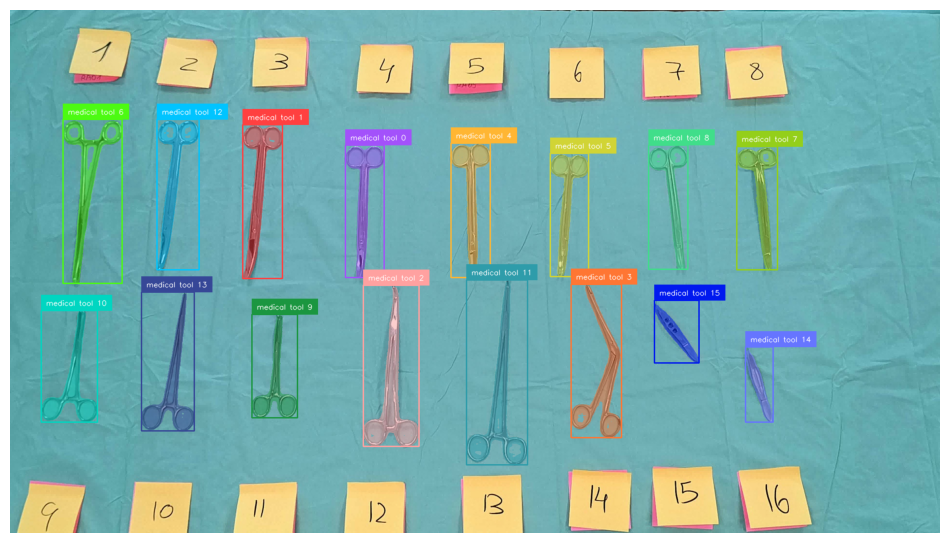

In [16]:
# Visualize masks
annotated_image = image.copy()
mask_annotator = sv.MaskAnnotator()

annotated_image = mask_annotator.annotate(annotated_image, detections)
annotated_image = box_annotator.annotate(annotated_image, detections)
annotated_image = label_annotator.annotate(annotated_image, detections, labels=[f"{l} {i}" for i, l in enumerate(labels)])

sv.plot_image(annotated_image)

## Video Tracking with SAM2

Now we'll propagate the masks through the video using SAM2's video predictor.

In [17]:
# Initialize video predictor state
inference_state = sam2_video_predictor.init_state(video_path=SOURCE_FRAMES.as_posix())
sam2_video_predictor.reset_state(inference_state)

# Add each detected object to the video predictor
for obj_id, mask in enumerate(best_masks):
    sam2_video_predictor.add_new_mask(
        inference_state=inference_state,
        frame_idx=0,
        obj_id=obj_id,
        mask=mask
    )
    print(f"Added object {obj_id} to video predictor")

print(f"\nInitialized tracking for {len(best_masks)} objects")

frame loading (JPEG): 100%|██████████| 1000/1000 [00:41<00:00, 24.23it/s]



Added object 0 to video predictor
Added object 1 to video predictor
Added object 2 to video predictor
Added object 3 to video predictor
Added object 4 to video predictor
Added object 5 to video predictor
Added object 6 to video predictor
Added object 7 to video predictor
Added object 8 to video predictor
Added object 9 to video predictor
Added object 10 to video predictor
Added object 11 to video predictor
Added object 12 to video predictor
Added object 13 to video predictor
Added object 14 to video predictor
Added object 15 to video predictor

Initialized tracking for 16 objects


In [19]:
# Propagate masks through video and save result
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO)
video_info.width = int(video_info.width * SCALE_FACTOR)
video_info.height = int(video_info.height * SCALE_FACTOR)

SOURCE_FRAME_PATHS = sorted(sv.list_files_with_extensions(SOURCE_FRAMES.as_posix(), extensions=["jpeg"]))

with sv.VideoSink(TARGET_VIDEO.as_posix(), video_info=video_info) as sink:
    for frame_idx, object_ids, mask_logits in tqdm(
        sam2_video_predictor.propagate_in_video(inference_state),
        desc="Processing frames",
        total=len(SOURCE_FRAME_PATHS)
    ):
        # Load frame
        frame_path = SOURCE_FRAME_PATHS[frame_idx]
        frame = cv2.imread(frame_path)
        
        # Convert mask logits to binary masks
        masks = (mask_logits > 0.0).cpu().numpy()
        masks = masks.astype(bool)
        
        # Create detections for this frame
        frame_detections = sv.Detections(
            xyxy=sv.mask_to_xyxy(masks=masks[:, 0, :]),
            mask=masks[:, 0, :],
            class_id=np.array(object_ids)
        )
        
        # Annotate frame (only masks, no labels)
        annotated_frame = mask_annotator.annotate(scene=frame.copy(), detections=frame_detections)
        
        # Write to output video
        sink.write_frame(annotated_frame)

print(f"\nTracking complete! Video saved to: {TARGET_VIDEO}")

Processing frames: 100%|██████████| 1000/1000 [34:55<00:00,  2.10s/it]


Tracking complete! Video saved to: c:\Users\asiel\OneDrive\Documents\Trackimed_New\demo 7-grounded-result.mp4


In [ ]:
# Optional: Display a sample frame from the output video
sample_frame_idx = len(SOURCE_FRAME_PATHS) // 2  # Middle frame
sample_frame_path = SOURCE_FRAME_PATHS[sample_frame_idx]
sample_frame = cv2.imread(sample_frame_path)
sample_frame_rgb = cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB)

print(f"Sample frame at index {sample_frame_idx}:")
sv.plot_image(sample_frame_rgb)